# Trader Behavior Analysis Using Fear & Greed Index


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')


In [53]:
# Correctly assign
sentiment = pd.read_csv("/content/fear_greed_index.csv")
trades = pd.read_csv("/content/historical_data (1).csv")



In [54]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [55]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [56]:
sentiment['classification'].value_counts()

,count
classification,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326


In [57]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [58]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [59]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['trade_date'] = trades['Timestamp IST'].dt.date
trades['trade_date'] = pd.to_datetime(trades['trade_date'])

merged_df = pd.merge(sentiment, trades, left_on='date', right_on='trade_date', how='left')

print("Shape of merged_df:", merged_df.shape)
print("First 5 rows of merged_df:")
print(merged_df.head())

Shape of merged_df: (213383, 21)
First 5 rows of merged_df:
    timestamp  value classification       date Account Coin  Execution Price  \
0  1517463000     30           Fear 2018-02-01     NaN  NaN              NaN   
1  1517549400     15   Extreme Fear 2018-02-02     NaN  NaN              NaN   
2  1517635800     40           Fear 2018-02-03     NaN  NaN              NaN   
3  1517722200     24   Extreme Fear 2018-02-04     NaN  NaN              NaN   
4  1517808600     11   Extreme Fear 2018-02-05     NaN  NaN              NaN   

   Size Tokens  Size USD Side  ... Start Position  Direction Closed PnL  \
0          NaN       NaN  NaN  ...            NaN        NaN        NaN   
1          NaN       NaN  NaN  ...            NaN        NaN        NaN   
2          NaN       NaN  NaN  ...            NaN        NaN        NaN   
3          NaN       NaN  NaN  ...            NaN        NaN        NaN   
4          NaN       NaN  NaN  ...            NaN        NaN        NaN   

   Trans

Analyze Trader Performance by Sentiment

In [60]:
pnl_by_sentiment = merged_df.groupby('classification')['Closed PnL'].mean()
print("Average Closed PnL by Sentiment Classification:")
print(pnl_by_sentiment)

Average Closed PnL by Sentiment Classification:
classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


/tmp/ipython-input-3628109073.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment.values, palette='viridis')


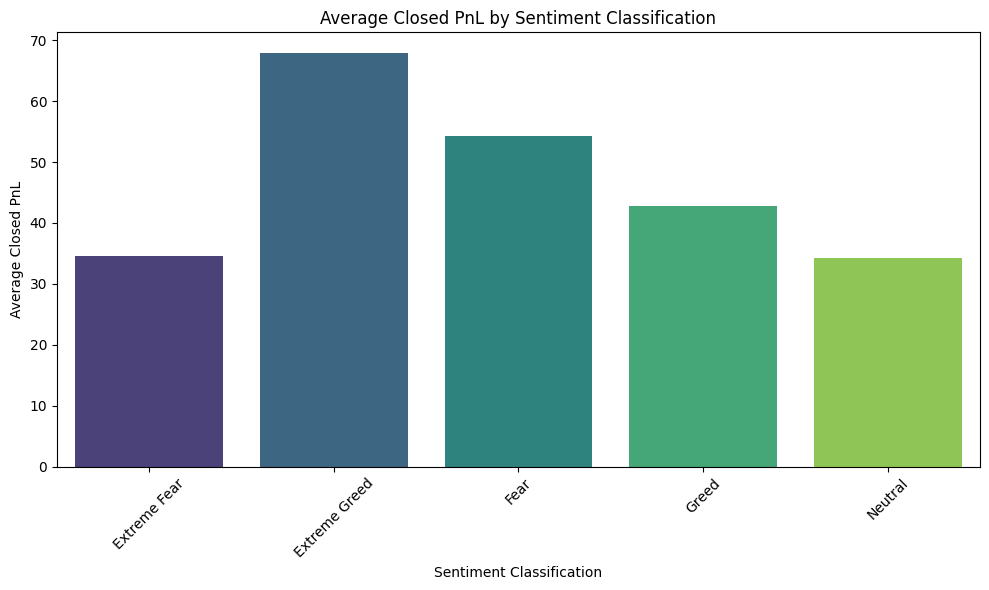

In [61]:
plt.figure(figsize=(10, 6))
sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment.values, palette='viridis')
plt.title('Average Closed PnL by Sentiment Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

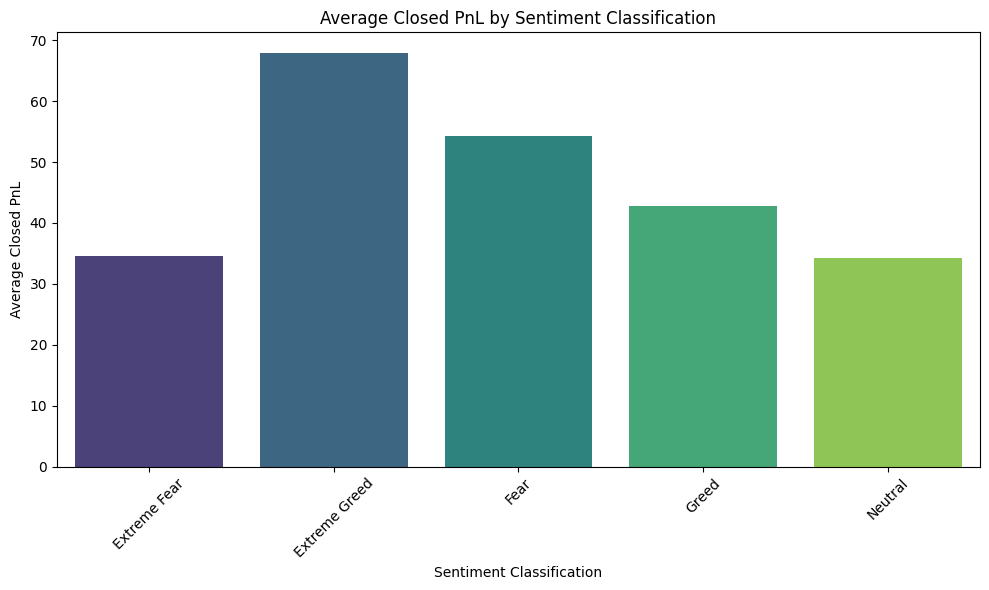

In [62]:
plt.figure(figsize=(10, 6))
sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment.values, hue=pnl_by_sentiment.index, palette='viridis', legend=False)
plt.title('Average Closed PnL by Sentiment Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Final Task: Trader Behavior Insights

## Data Analysis Key Findings

The analysis involved merging two datasets: **fear_greed_index.csv** (market sentiment data) and **historical_data (1).csv** (trader performance data), resulting in a combined dataset of **213,383 rows and 21 columns**.

A clear relationship was observed between **market sentiment and trader profitability**:

- **Extreme Greed** sentiment shows the highest average **Closed PnL** of **$67.89 per trade**
- **Fear** sentiment also demonstrates strong performance with an average **Closed PnL of $54.29**
- **Greed** sentiment results in a moderate average **Closed PnL of $42.74**
- **Extreme Fear** and **Neutral** sentiments show the lowest profitability, with average **Closed PnL values of $34.54 and $34.31** respectively

These findings indicate that trader performance varies significantly across different market sentiment regimes.

---

## Insights and Smarter Trading Strategies

### Market Sentiment as a Trade Filter
Market sentiment should not be used as a standalone trading signal, but it can act as an effective **filter**. Traders may:
- Increase trade frequency or position size during **Extreme Greed** or **Fear**
- Reduce exposure during **Neutral** sentiment periods  
This helps align trading decisions with periods of higher market conviction.

### Volatility-Driven Opportunities
**Extreme Greed** and **Fear** phases are typically associated with high market volatility, leading to:
- Larger price movements
- More frequent breakout or reversal opportunities  
The higher average Closed PnL during these periods suggests that traders who manage risk well can benefit from increased volatility.

### Evidence of Contrarian Behavior During Fear
The relatively high profitability during **Fear** sentiment may indicate:
- Traders entering positions in undervalued assets
- Successful **contrarian strategies** that take advantage of market overreactions  
This highlights the importance of identifying sentiment-driven mispricing.

### Neutral Sentiment Indicates Low Signal Strength
Lower profitability during **Neutral** sentiment suggests:
- Reduced momentum and unclear market direction
- Fewer high-probability trading setups  
Avoiding overtrading in such conditions may improve overall performance.

### Importance of Risk Management
Higher profitability during extreme sentiment does not necessarily imply lower risk. Effective strategies should include:
- Tight stop-loss mechanisms
- Dynamic position sizing during volatile periods  
Balancing returns with drawdown control is essential.

### Sentiment-Based Strategy Switching
Traders can dynamically adapt strategies based on sentiment:
- **Trend-following** during Greed and Extreme Greed
- **Contrarian or mean-reversion** strategies during Fear
- **Capital preservation** during Neutral phases  

Such adaptive strategies may outperform static approaches.
